# Exploratory Data Analysis (EDA)

- Analyzing UCI Machine Learning Dermatology dataset
- Multi-class classification based on 34 features into 6 labels
- Includes 366 samples

### Load the Data

In [26]:
from ucimlrepo import fetch_ucirepo

derma_repo = fetch_ucirepo(id=33)

X = derma_repo.data.features
y = derma_repo.data.targets


### Initial Inspection

In [126]:
X.head().T

,0,1,2,3,4
erythema,2.0,3.0,2.0,2.0,2.0
scaling,2.0,3.0,1.0,2.0,3.0
definite-borders,0.0,3.0,2.0,2.0,2.0
itching,3.0,2.0,3.0,0.0,2.0
koebner phenomenon,0.0,1.0,1.0,0.0,2.0
polygonal papules,0.0,0.0,3.0,0.0,2.0
follicular papules,0.0,0.0,0.0,0.0,0.0
oral-mucosal involvement,0.0,0.0,3.0,0.0,2.0
knee elbow involvement,1.0,1.0,0.0,3.0,0.0
scalp involvement,0.0,1.0,0.0,2.0,0.0


In [28]:
y.head()

,class
0,2
1,1
2,3
3,1
4,3


In [29]:
X.shape

(366, 34)

In [30]:
y.shape

(366, 1)

In [31]:
X.dtypes

erythema                                         int64
scaling                                          int64
definite-borders                                 int64
itching                                          int64
koebner phenomenon                               int64
polygonal papules                                int64
follicular papules                               int64
oral-mucosal involvement                         int64
knee elbow involvement                           int64
scalp involvement                                int64
family history                                   int64
melanin incontinence                             int64
eosinophils in the infiltrate                    int64
pnl infiltrate                                   int64
fibrosis of the papillary dermis                 int64
exocytosis                                       int64
acanthosis                                       int64
hyperkeratosis                                   int64
parakerato

In [32]:
y.dtypes

class    int64
dtype: object

### Initial Inspection - Findings
- Data does correctly include **34 features** across **366 samples**
- All features and labels are **integers** besides age which is **float**

### Data Quality Check

In [33]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 34 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   erythema                                     366 non-null    int64  
 1   scaling                                      366 non-null    int64  
 2   definite-borders                             366 non-null    int64  
 3   itching                                      366 non-null    int64  
 4   koebner phenomenon                           366 non-null    int64  
 5   polygonal papules                            366 non-null    int64  
 6   follicular papules                           366 non-null    int64  
 7   oral-mucosal involvement                     366 non-null    int64  
 8   knee elbow involvement                       366 non-null    int64  
 9   scalp involvement                            366 non-null    int64  
 10  family histor

In [34]:
y.info()

<class 'pandas.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   class   366 non-null    int64
dtypes: int64(1)
memory usage: 3.0 KB


In [46]:
X['age'].isnull().sum()

np.int64(8)

In [47]:
X.duplicated().sum()

np.int64(0)

In [55]:
ordinal_cols = X.columns.drop('age')
X[ordinal_cols].apply(lambda col: col.between(0, 3).all())

erythema                                       True
scaling                                        True
definite-borders                               True
itching                                        True
koebner phenomenon                             True
polygonal papules                              True
follicular papules                             True
oral-mucosal involvement                       True
knee elbow involvement                         True
scalp involvement                              True
family history                                 True
melanin incontinence                           True
eosinophils in the infiltrate                  True
pnl infiltrate                                 True
fibrosis of the papillary dermis               True
exocytosis                                     True
acanthosis                                     True
hyperkeratosis                                 True
parakeratosis                                  True
clubbing of 

In [82]:
X['family history'].between(0, 1).all()

np.True_

In [76]:
(X['age'].dropna() >= 0).all()

np.True_

In [84]:
X['age'].max()

np.float64(75.0)

In [85]:
X.index.equals(y.index)

True

In [89]:
y['class'].isin(range(1,7)).all()

np.True_

### Data Quality - Findings
- Age has 8 missing values; none other found
- No duplicate rows found in feature set X
- All ordinal features are between [0, 3]; Family history is strictly between [0, 1] which is correct
- All valid ages are positive
- Ages between 0-75
- inflammatory mononuclear infiltrate is spelled incorrectly
- Class labels are within valid 1-6 range

### Target Analysis

In [94]:
y['class'].value_counts()

class
1    112
3     72
2     61
5     52
4     49
6     20
Name: count, dtype: int64

<Axes: xlabel='class'>

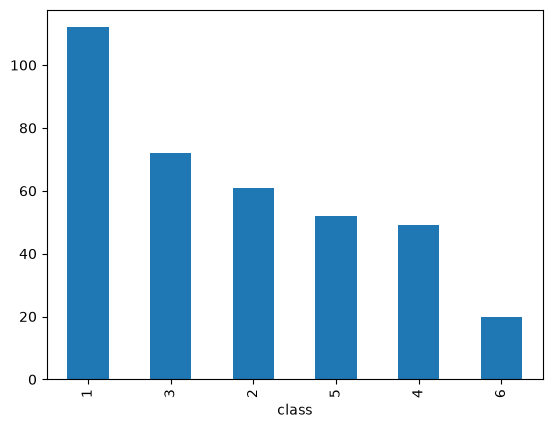

In [93]:
y['class'].value_counts().plot(kind='bar')

### Target Analysis - Findings
- Class imbalance across label set
- class 1 (psoriasis) is the dominant class at 112 samples
- class 6 (pityroasos rubra pilaris) is the smallest class at 20 samples
- utilizing accuracy will be misleading -> use stratified splits to preserce class proportions, evaluate with macro-F1, consider class weighting if needed

### Univariate Analysis

<Axes: >

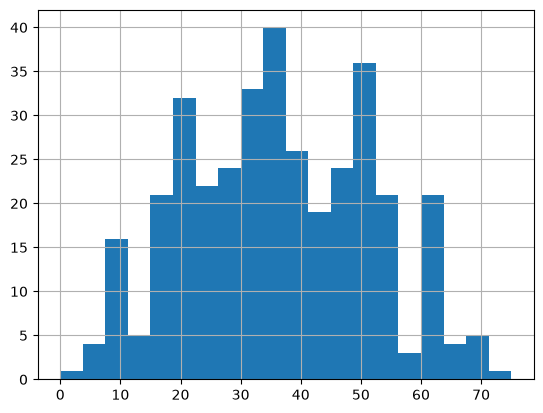

In [101]:
X['age'].hist(bins=20)

In [102]:
X['age'].describe()

count    358.000000
mean      36.296089
std       15.324557
min        0.000000
25%       25.000000
50%       35.000000
75%       49.750000
max       75.000000
Name: age, dtype: float64

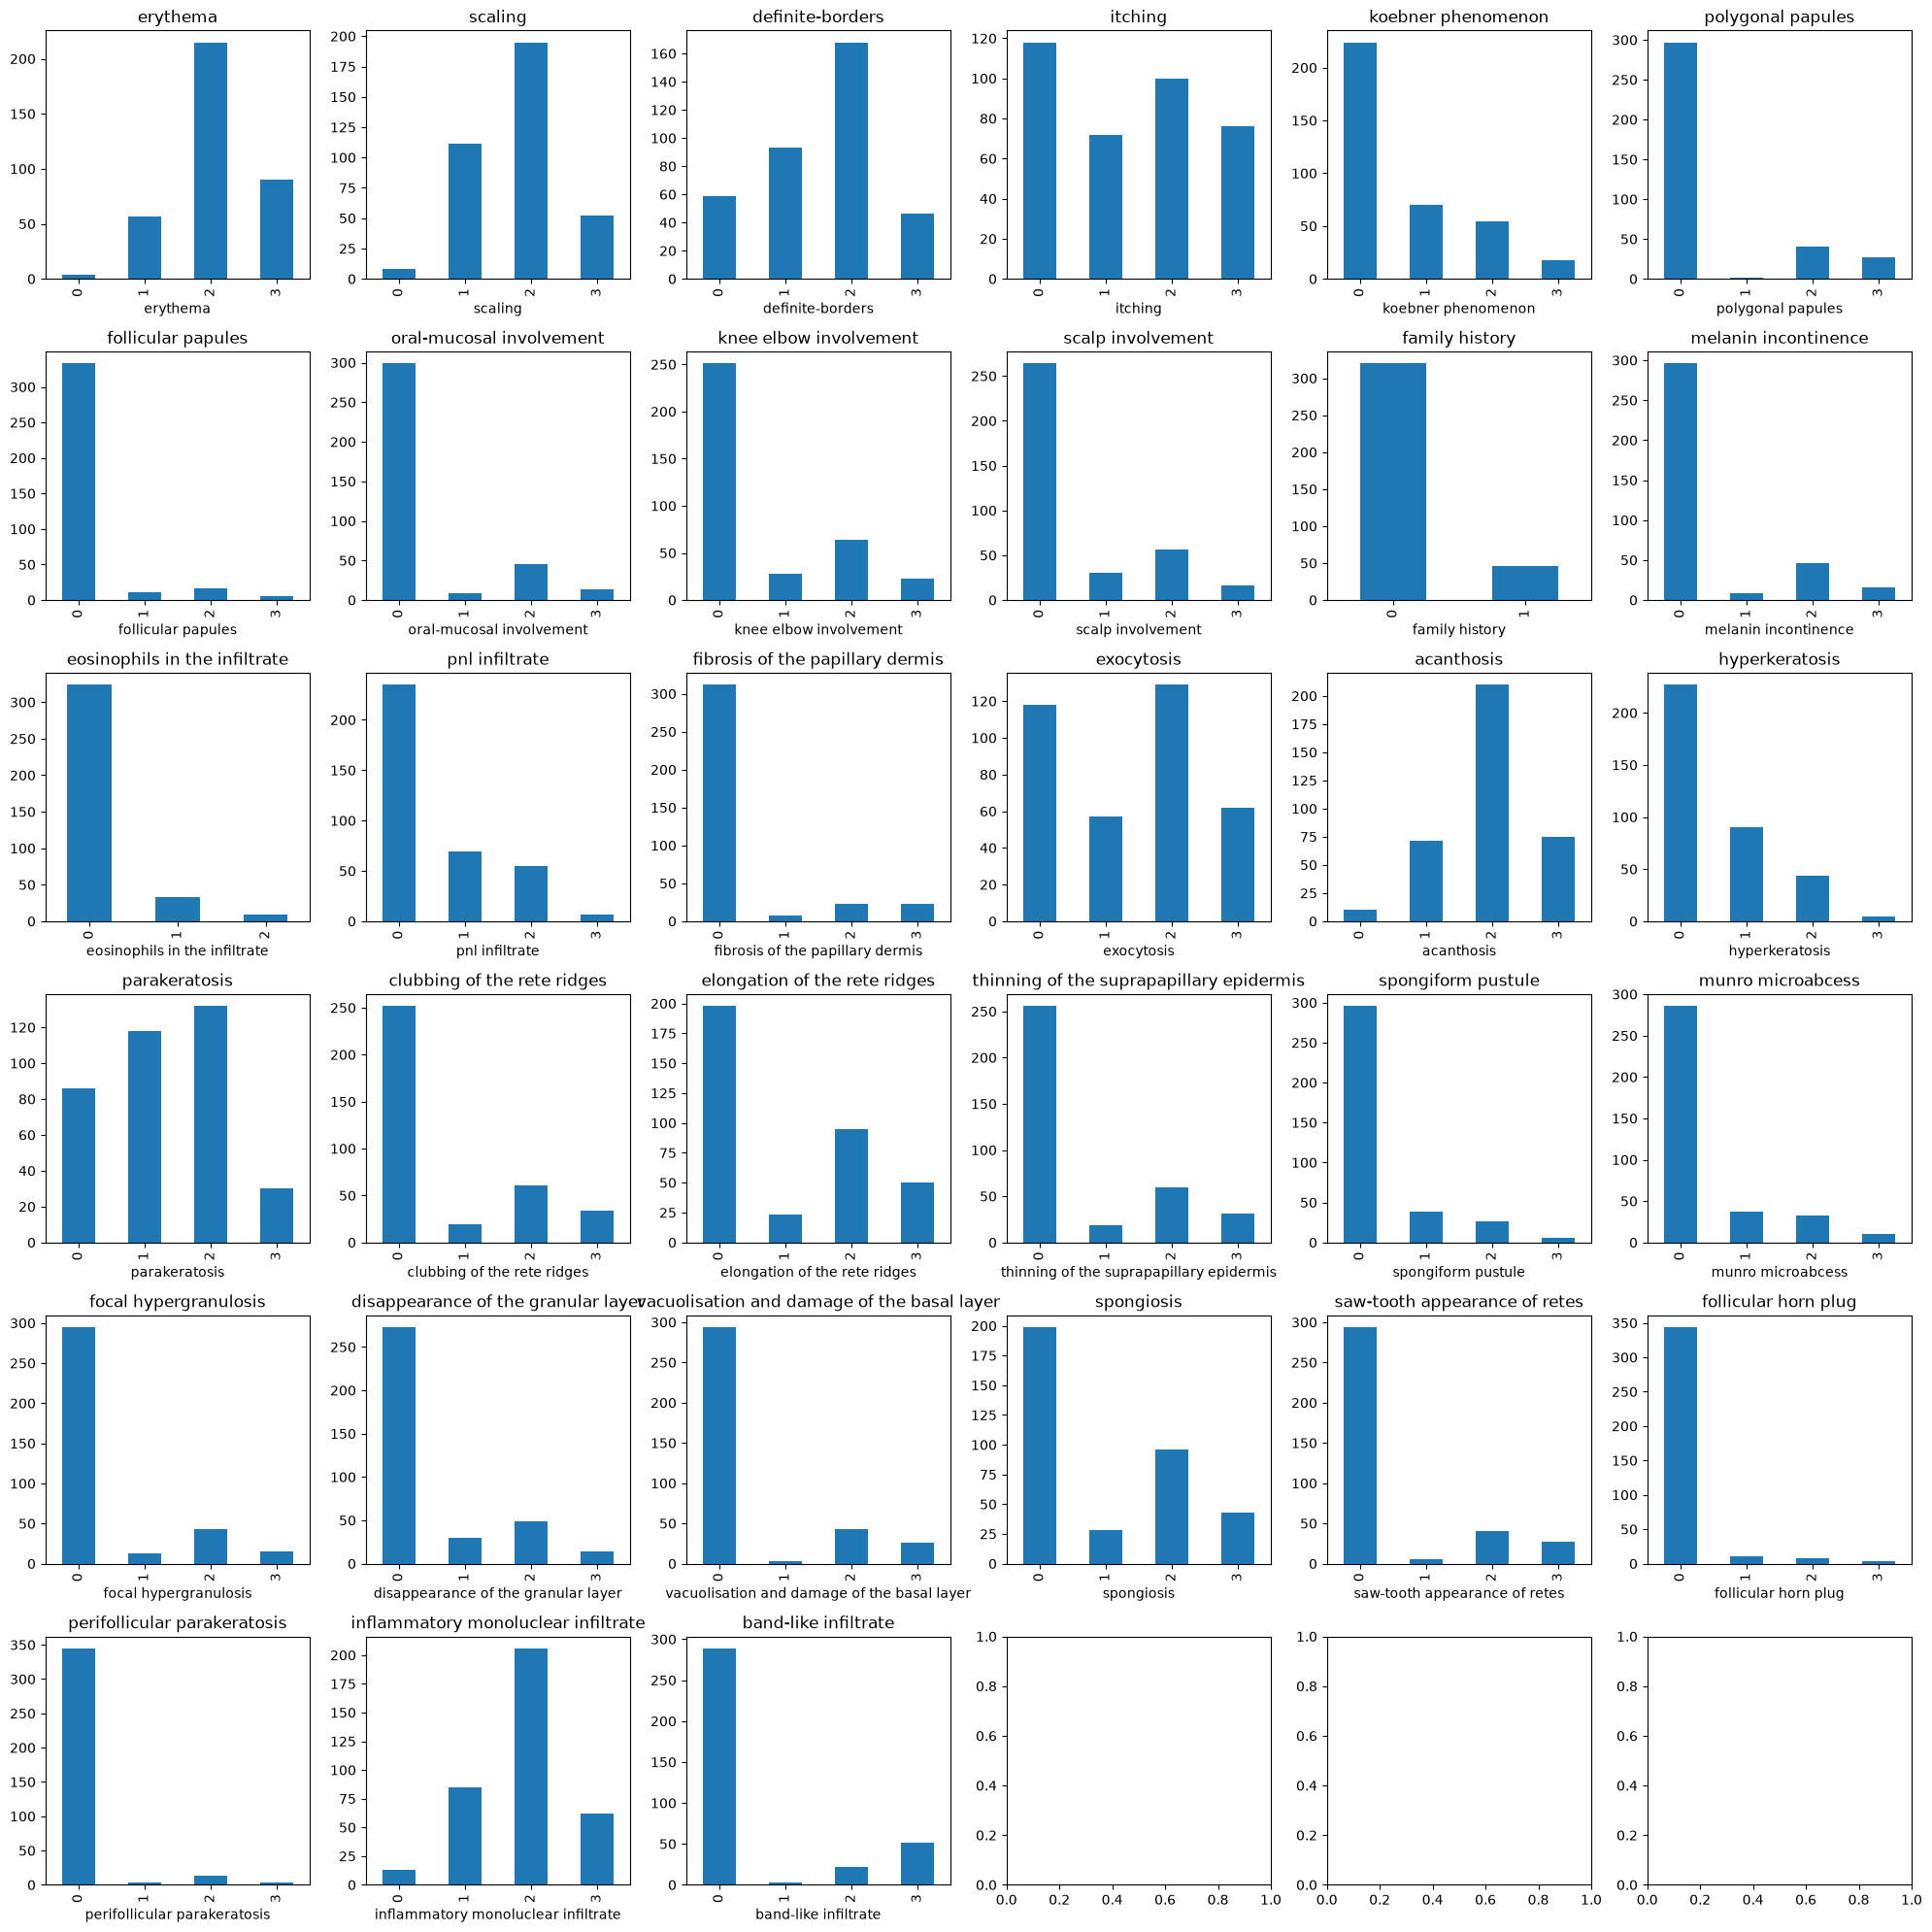

In [124]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(6, 6, figsize=(20, 20))
for col, ax in zip(ordinal_cols, axs.flatten()):
    X[col].value_counts().sort_index().plot(kind='bar', ax=ax)
    ax.set_title(col, fontsize=12)
plt.tight_layout()

### Univariate Analysis - Findings
- Average is 35 with a std of 15 (20 & 50 has highest peaks after average)
- Most of the histopathological features are heavily skewed toward 0 (absence) as they're rare, disease-specific markers
- Smaller set of features are more evenly spread out (itching, exocytosis, parakeratosis) - possible signals
- No feature is fully constant
- No feature has a 0 samples under its severity level
- Confirms earilier Data Quality range check [0, 3]

### Bivariate Analysis


In [125]:
X.groupby(y['class']).mean().T

class,1,2,3,4,5,6
erythema,2.285714,2.278689,2.083333,1.897959,1.500000,2.05
scaling,2.196429,2.065574,1.625000,1.510204,1.134615,1.75
definite-borders,2.098214,0.950820,2.097222,1.183673,0.846154,1.05
itching,0.946429,1.622951,2.277778,0.469388,1.884615,0.50
koebner phenomenon,0.669643,0.032787,1.347222,1.183673,0.000000,0.00
polygonal papules,0.000000,0.000000,2.277778,0.000000,0.000000,0.00
follicular papules,0.035714,0.016393,0.000000,0.000000,0.230769,2.20
oral-mucosal involvement,0.000000,0.000000,1.916667,0.000000,0.000000,0.00
knee elbow involvement,1.633929,0.065574,0.027778,0.000000,0.038462,1.70
scalp involvement,1.526786,0.114754,0.027778,0.000000,0.000000,0.50


In [127]:
sns.boxplot(x=y['class'].values.ravel(), y=X['polygonal papules'])

NameError: name 'sns' is not defined